# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [ ]:
import pandas as pd

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [ ]:
from sklearn.model_selection import train_test_split
y = df['salary_in_usd']
X = df.drop(['salary_in_usd', 'salary'], axis = 1)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
# -- YOUR CODE HERE --

## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
import numpy as np

categorical_features = ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_val_cat = encoder.transform(X_val[categorical_features])
X_train_coded = np.hstack([X_train_cat, X_train[['work_year', 'remote_ratio']]])
X_val_coded = np.hstack([X_val_cat, X_val[['work_year', 'remote_ratio']]])
linreg = LinearRegression()
linreg.fit(X_train_coded, y_train)
y_pred = linreg.predict(X_val_coded)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mape = mean_absolute_percentage_error(y_val, y_pred)

print('MAPE: ', mape)
print('RMSE: ', rmse)

MAPE:  0.4302285520612761
RMSE:  46842.078054970254


## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [ ]:
from xgboost.sklearn import XGBRegressor
import time
from sklearn.model_selection import RandomizedSearchCV
xgb = XGBRegressor(random_state=42)

param_dist = {
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_percentage_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train_coded, y_train)
print("Лучшие параметры:", search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Лучшие параметры: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}


In [ ]:
# -- YOUR CODE HERE --
params = {
    'max_depth' : 10,
    'learning_rate' : 0.1,
    'n_estimators' : 50,
    'gamma' : 0,
    'subsample' : 0.8,
    'colsample_bytree' : 1.0,
    'random_state': 42
}
xgbreg = XGBRegressor(**params)
start_train = time.time()
xgbreg.fit(X_train_coded, y_train)
end_train = time.time()
start_pred = time.time()
y_pred = xgbreg.predict(X_val_coded)
end_pred = time.time()
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mape = mean_absolute_percentage_error(y_val, y_pred)

print('MAPE:', round(mape, 4))
print('RMSE:', round(rmse, 2))
print('Время обучения: ', end_train - start_train)
print('Время предсказания: ', end_pred - start_pred)

MAPE: 0.3904
RMSE: 45923.48
Время обучения:  0.13964390754699707
Время предсказания:  0.0023651123046875


## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.2 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV

model = CatBoostRegressor(verbose=0)

param_grid = {
    'depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'iterations': [100, 200, 300, 500]

}

grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_root_mean_squared_error', cv=3)
grid.fit(X_train_coded, y_train)

print("Best params:", grid.best_params_)

Best params: {'depth': 7, 'iterations': 500, 'learning_rate': 0.05}


In [ ]:
from catboost import CatBoostRegressor
params = {
    'depth' : 7,
    'learning_rate' : 0.05,
    'iterations' : 500,
    'loss_function': 'RMSE',
    'verbose': 0,
    'random_seed': 42
}
catboost = CatBoostRegressor(**params)
start_train = time.time()
catboost.fit(X_train_coded, y_train)
end_train = time.time()
start_pred = time.time()
y_pred = catboost.predict(X_val_coded)
end_pred = time.time()

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mape = mean_absolute_percentage_error(y_val, y_pred)

print('MAPE:', round(mape, 4))
print('RMSE:', round(rmse, 2))
print('Время обучения: ', end_train - start_train)
print('Время предсказания: ', end_pred - start_pred)

MAPE: 0.3925
RMSE: 45150.11
Время обучения:  2.308793067932129
Время предсказания:  0.07355666160583496


Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [ ]:
from catboost import Pool
train_pool = Pool(data=X_train,
                  label=y_train,
                  cat_features=categorical_features)

val_pool = Pool(data=X_val,
                label=y_val,
                cat_features=categorical_features)
params = {
    'depth' : 7,
    'learning_rate' : 0.05,
    'iterations' : 500,
    'loss_function': 'RMSE',
    'verbose': 0,
    'random_seed': 42
}
start_train = time.time()
catboost.fit(train_pool)
end_train = time.time()

start_pred = time.time()
y_pred = catboost.predict(val_pool)
end_pred = time.time()
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mape = mean_absolute_percentage_error(y_val, y_pred)

print('MAPE:', round(mape, 4))
print('RMSE:', round(rmse, 2))
print('Время обучения: ', end_train - start_train)
print('Время предсказания: ', end_pred - start_pred)

MAPE: 0.4262
RMSE: 45365.19
Время обучения:  3.5319223403930664
Время предсказания:  0.0012400150299072266


**Ответ:** время обучения увеличилось (более чем на 1 сек), а время предсказания заметно уменьшилось (в 60 раз), качество стало немного хуже и по MAPE и по RMSE

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [ ]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
lgbmreg = LGBMRegressor(random_state=42)
param_grid = {
    'max_depth': [2, 4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.3],
    'n_estimators': [100,200,300],
}
grid_search = GridSearchCV(
    estimator=lgbmreg,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_coded, y_train)
print("Лучшие параметры:", grid_search.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 86
[LightGBM] [Info] Number of data points in the train set: 3004, number of used features: 41
[LightGBM] [Info] Start training from score 138055.989348
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:

params = {
    'max_depth': 2,
    'learning_rate': 0.1,
    'n_estimators': 300
}
lgbmreg = LGBMRegressor(**params)
start_train = time.time()
lgbmreg.fit(X_train_coded, y_train)
end_train = time.time()
start_pred = time.time()
y_pred = lgbmreg.predict(X_val_coded)
end_pred = time.time()
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mape = mean_absolute_percentage_error(y_val, y_pred)

print('MAPE:', round(mape, 4))
print('RMSE:', round(rmse, 2))
print('Время обучения: ', end_train - start_train)
print('Время предсказания: ', end_pred - start_pred)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 86
[LightGBM] [Info] Number of data points in the train set: 3004, number of used features: 41
[LightGBM] [Info] Start training from score 138055.989348
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

**Ответ:** XGBRegressor: MAPE: 0.3904; RMSE: 45923.48; Время обучения:  0.13964390754699707; Время предсказания:  0.0023651123046875

CatBoostRegressor: MAPE: 0.3925; RMSE: 45150.11; Время обучения:  2.308793067932129; Время предсказания:  0.07355666160583496

CatBoostRegressor без предварительного кодирования категориальных данных: MAPE: 0.4262; RMSE: 45365.19; Время обучения:  3.5319223403930664; Время предсказания:  0.0012400150299072266

LGBMRegressor: MAPE: 0.3982; RMSE: 45734.82; Время обучения:  0.06569623947143555; Время предсказания:  0.005002021789550781

По качеству: наименьшую абсолютную ошибку (RMSE = 45150.11) показал CatBoostRegressor с ручной кодировкой категориальных признаков. Наименьшую относительную ошибку (MAPE = 0.3904) дал XGBRegressor. Наихудший результат по MAPE (0.4262) показал CatBoost с автоматической обработкой категориальных признаков через cat_features

По скорости обучения: самым быстрым оказался LGBMRegressor (0.066 сек), за ним — XGBRegressor (0.14 сек). CatBoost с cat_features обучался дольше всех (3.53 сек)

По скорости предсказания: самым быстрым оказался CatBoost с cat_features (0.0012 сек), чуть медленнее — XGBRegressor и LGBMRegressor.

Различия в параметрах:


Глубина дерева: для XGBRegressor -	max_depth=10 (глубоко); для CatBoostRegressor -	depth=7 (средне); для LGBMRegressor -	max_depth=2 (очень мелко)

Скорость обучения: для XGBRegressor -	learning_rate=0.1; для CatBoostRegressor -	learning_rate=0.05; для LGBMRegressor - learning_rate=0.1

Кол-во деревьев/итераций:	для XGBRegressor -	n_estimators=50 (мало); 	для CatBoostRegressor -	iterations=500 (много); для LGBMRegressor -	n_estimators=300 (средне)

XGBRegressor обучается быстро (мало деревьев), с высокой глубиной (рискует переобучиться), и использует частичное сэмплирование

CatBoost обучается дольше (500 итераций), но с умеренной глубиной и низким learning_rate - это даёт устойчивую модель

LGBMRegressor работает быстрее всех, имеет низкую глубину дерева, что ограничивает переобучение, но может проигрывать в точности



# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [2]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [5]:
ratings_t = ratings.T

Выкиньте строку под названием `user`.

In [6]:
ratings_t = ratings_t.drop('user')

В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [8]:
ratings = ratings_t.fillna(0)
ratings.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
kaiser thiefs,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [9]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(ratings)
ratings['cluster'] = labels
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4991,4992,4993,4994,4995,4996,4997,4998,4999,cluster
the beatles,0.000000,0.000000,0.000000,0.0,0.043529,0.000000,0.0,0.0,0.093398,0.017621,...,0.0,0.121169,0.038168,0.007939,0.017884,0.0,0.076923,0.0,0.000000,4
radiohead,0.020417,0.184962,0.000000,0.0,0.086281,0.006322,0.0,0.0,0.000000,0.019156,...,0.0,0.000000,0.000000,0.011187,0.000000,0.0,0.000000,0.0,0.000000,0
deathcab for cutie,0.000000,0.024561,0.028635,0.0,0.034590,0.000000,0.0,0.0,0.000000,0.013349,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.027893,0
coldplay,0.000000,0.000000,0.000000,0.0,0.016712,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0
modest mouse,0.000000,0.000000,0.000000,0.0,0.015935,0.000000,0.0,0.0,0.000000,0.030437,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0


Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [10]:
ratings['cluster'].value_counts().sort_index()

,count
cluster,
0,115
1,1
2,1
3,882
4,1


**Ответ:** Нет, результаты кластеризации с помощью KMeans оказались неинформативными: кластер 3 содержит 882 исполнителя, кластер 0 — 115, а кластеры 1, 2 и 4 — по 1 исполнителю. Такой сильный дисбаланс говорит о том, что модель не смогла выявить устойчивых групп похожих исполнителей. Это связано с разреженностью данных — большинство пользователей слушает ограниченное число артистов, из-за чего векторы получаются малопересекающимися. Кроме того, KMeans плохо работает с такими разреженными данными, особенно без предварительной нормализации. Для более качественной кластеризации стоит попробовать другие алгоритмы (например, DBSCAN или иерархическую кластеризацию)

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [12]:
cluster_counts = ratings['cluster'].value_counts()
small_clusters = cluster_counts[cluster_counts == 1].index
unique_cluster_artists = ratings[ratings['cluster'].isin(small_clusters)].index
unique_cluster_artists

Index(['the beatles', 'niИ', '日dir en grey'], dtype='object')


Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [14]:
listen_rate = (ratings.drop(columns='cluster') > 0).mean(axis=1)
avg_share = ratings.drop(columns='cluster').mean(axis=1)
listen_rate['the beatles'], avg_share['the beatles']

(np.float64(0.3342), np.float64(0.01836897659205146))

**Ответ:** У исполнителя The Beatles доля слушателей составляет 33.4%, а средняя доля прослушивания всего 1.84%, это означает, что The Beatles слушает треть пользователей, но в среднем они уделяют им совсем немного времени. Такой профиль отличается от большинства других исполнителей — обычно либо меньше пользователей слушают, но с большим интересом, либо охват и доля более сбалансированы. Именно из-за широкой, но неглубокой аудитории прослушивания, The Beatles выделяются и попадают в отдельный кластер как уникальный случай

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [15]:
from sklearn.preprocessing import normalize
ratings_norm = normalize(ratings.drop(columns='cluster'), axis=1)
ratings_norm = pd.DataFrame(ratings_norm, index=ratings.index, columns=ratings.columns.drop('cluster'))
# -- YOUR CODE HERE --

Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [18]:
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(ratings_norm)
ratings['cluster_norm'] = cluster_labels
ratings['cluster_norm'].value_counts()

,count
cluster_norm,
4,486
1,162
3,140
2,133
0,79


**Ответ** да, кластеризация стала значительно лучше и полезнее после нормализации, кластеры теперь сбалансированы — нет кластеров с 1 элементом, как раньше, это значит, что KMeans начал учитывать схожесть структуры прослушивания, а не абсолютные значения

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [22]:
from scipy.spatial.distance import cosine


centroids = kmeans.cluster_centers_
atings_norm_df = pd.DataFrame(ratings_norm, index=ratings.index, columns=ratings.columns.drop(['cluster', 'cluster_norm']))
top_artists_by_cluster = {}
for cluster_id in range(centroids.shape[0]):
    centroid = centroids[cluster_id]
    distances = ratings_norm.apply(lambda x: cosine(x.values, centroid), axis=1)
    top_artists = distances.nsmallest(10).index.tolist()
    top_artists_by_cluster[cluster_id] = top_artists

for cluster, artists in top_artists_by_cluster.items():
    print(f"Cluster {cluster}:")
    for artist in artists:
        print(artist)
    print()

Cluster 0:
nas
jay-z
kanye west
lupe the gorilla
a tribe called quest
the roots featuring d'angelo
gangstarr
little brother
lil' wayne
murs and 9th wonder

Cluster 1:
fall out boy
the all-americian rejects
paramore
kelly clarkson
john mayer
the fray
maroon5
dashboard confesssional
somethings corporate
coldplay

Cluster 2:
brand new
blink-182
alkaline trio
against me!
underoath
descendents
new found glory
less than jake
thrice
chiodos

Cluster 3:
the beatles
the rolling stones
dylan. bob
who
led zeppelin.
miles davis.
simon and garfunkel
young, neil
pink fluid
velvet underground

Cluster 4:
radiohead
the arcade fire
the shins
sufjan stevens
belle and sebastian
broken social scene
the pixies
animal collective
modest mouse
spoon



**Ответ:** Кластеры отражают жанровые предпочтения слушателей. Cluster 0 объединяет любителей рэпа (Nas, Jay-Z, Kanye West...), Cluster 1 — мейнстрим-поп и поп-рок (Fall Out Boy, Maroon 5, Coldplay...) и так далее. В целом видим, что кластеризация хорошо сработала, разделив исполнителей на группы по жанрам

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

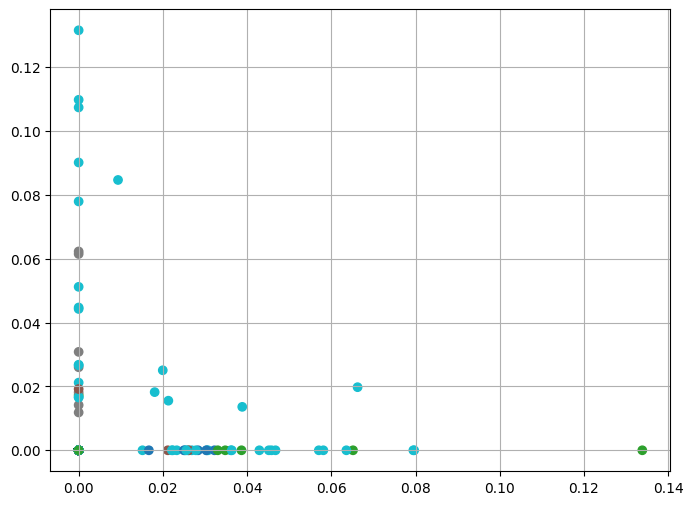

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(ratings_norm[ratings_norm.columns[0]], ratings_norm[ratings_norm.columns[1]], c=cluster_labels, cmap='tab10')
plt.grid(True)
plt.show()


**Ответ:** Визуализация получилась малоинформативной, потому что мы отобразили данные в двух измерениях (по двум пользователям), тогда как кластеризация выполнялась в многомерном пространстве — по всем пользователям сразу. Из-за этого большинство точек сгруппированы у нуля - пользователи слушают ограниченное число исполнителей, и у многих артистов доли прослушивания по выбранным пользователям близки к нулю; разделение кластеров визуально нечёткое, так как они хорошо отделимы только в полной размерности (в пространстве всех признаков), а не в двумерной проекции

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

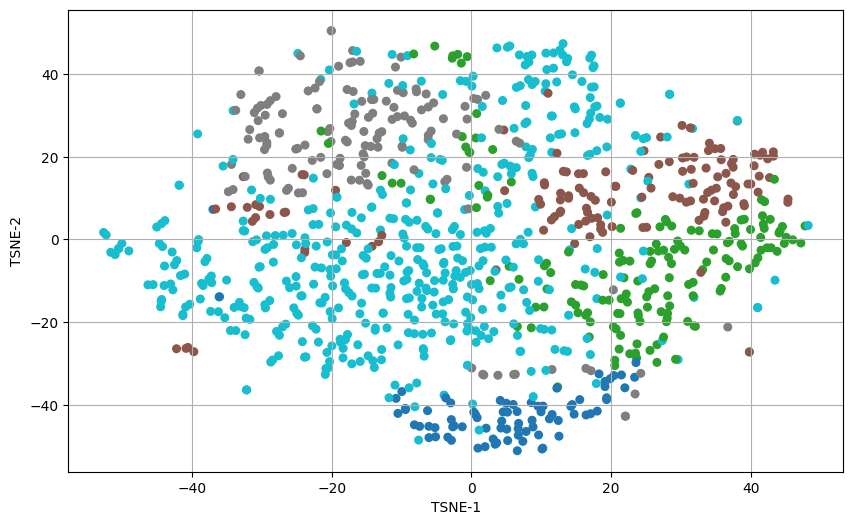

In [39]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
ratings_tsne = tsne.fit_transform(ratings_norm)
plt.figure(figsize=(10, 6))
plt.scatter(ratings_tsne[:, 0], ratings_tsne[:, 1], c=cluster_labels, cmap='tab10', s=30)
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.grid(True)
plt.show()

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

In [40]:
from sklearn.metrics import silhouette_score

best_score = -1
best_k = None
scores = []
for k in range(2, 101):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(ratings_norm)
    score = silhouette_score(ratings_norm, labels)
    scores.append(score)
    if score > best_score:
        best_score = score
        best_k = k
best_k, best_score

(98, np.float64(0.01332710844154191))

Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [41]:
kmeans = KMeans(n_clusters=98, random_state=42, n_init='auto')
ratings['cluster_98'] = kmeans.fit_predict(ratings_norm)
centroids = kmeans.cluster_centers_

for i in range(98):
    cluster_data = ratings_norm[ratings['cluster_98'] == i]
    closest = cluster_data.apply(lambda x: cosine(x, centroids[i]), axis=1).idxmin()
    print(f"Cluster {i}: {closest}")

Cluster 0: dr. dre
Cluster 1: john mayer
Cluster 2: white stripes
Cluster 3: fugazi
Cluster 4: ryan adams
Cluster 5: dj shadow
Cluster 6: system of a down
Cluster 7: somethings corporate
Cluster 8: chiodos
Cluster 9: the police
Cluster 10: j dilla
Cluster 11: alicia keys
Cluster 12: sufjan stevens
Cluster 13: digitalism
Cluster 14: john lenon
Cluster 15: chris brown
Cluster 16: 3oh!3
Cluster 17: the cure
Cluster 18: van hallen
Cluster 19: deerhunter
Cluster 20: pelican
Cluster 21: newsboys
Cluster 22: the goo goo dools
Cluster 23: sum41
Cluster 24: coconut records
Cluster 25: soundgarden
Cluster 26: as i lay dying
Cluster 27: kelly clarkson
Cluster 28: eminem
Cluster 29: lynyrd skynyrd-
Cluster 30: alkaline trio
Cluster 31: nofx
Cluster 32: catch 22
Cluster 33: prefuse 73
Cluster 34: tricky & dj muggs & grease
Cluster 35: dylan. bob
Cluster 36: built to spill
Cluster 37: danzig
Cluster 38: lady gaga
Cluster 39: arch enemy
Cluster 40: sigur rós
Cluster 41: the temptations
Cluster 42: gi

**Ответ:** Смысл кластеров после увеличения их числа до 98 стал более узким, ранее крупные музыкальные категории (рок, хип-хоп, ...) теперь распались на отдельные поджанры или даже уникальные стили, кластеризация стала более точной, но менее интерпретируемой на высоком уровне, это полезно для персонализированных рекомендаций, но хуже для широкой сегментации слушателей

Сделайте t-SNE визуализацию полученной кластеризации.

In [ ]:
# -- YOUR CODE HERE --

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

In [ ]:
# -- YOUR CODE HERE --

**Ответ:** # -- YOUR ANSWER HERE --